<a href="https://colab.research.google.com/github/IsaacMartindeDiego/MAT_IA_TAJAMAR/blob/Tema_2/or_perceptron_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matemáticas para la IA: Álgebra y Optimización

# Caso de uso aplicado: OR lógico con perceptrón simple

Este cuaderno muestra un ejemplo completo de aprendizaje supervisado con:

- **Datos**: compuerta lógica OR con dos variables de entrada
- **Modelo**: perceptrón simple con activación sigmoide
- **Optimización**: descenso por gradiente
- **Visualización**: pérdida, predicciones y frontera de decisión

## Objetivos

1. Representar el problema OR como un conjunto de datos.
2. Definir un modelo lineal sencillo.
3. Ajustar sus parámetros mediante gradiente descendente.
4. Interpretar geométricamente la frontera de decisión.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Datos: compuerta OR

La tabla de verdad de la compuerta OR es:

| x1 | x2 | y |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1 |

Cada observación se representa como un vector \(x = (x_1, x_2)\).

In [2]:
# Datos del OR lógico
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = np.array([[0.0],
              [1.0],
              [1.0],
              [1.0]])

print("X =")
print(X)
print("\ny =")
print(y)

X =
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

y =
[[0.]
 [1.]
 [1.]
 [1.]]


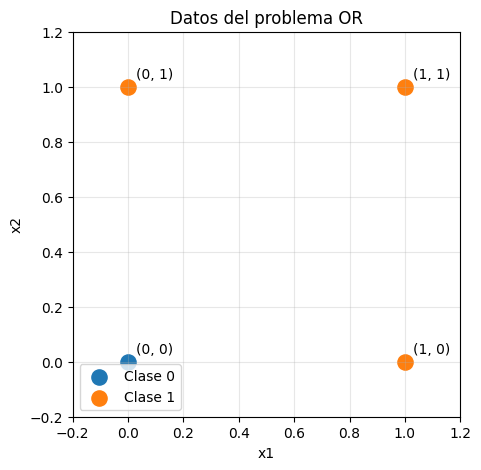

In [3]:
plt.figure(figsize=(5, 5))

mask0 = (y.ravel() == 0)
mask1 = (y.ravel() == 1)

plt.scatter(X[mask0, 0], X[mask0, 1], s=120, label="Clase 0")
plt.scatter(X[mask1, 0], X[mask1, 1], s=120, label="Clase 1")

for i, (x1, x2) in enumerate(X):
    plt.text(x1 + 0.03, x2 + 0.03, f"({int(x1)}, {int(x2)})", fontsize=10)

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Datos del problema OR")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Interpretación geométrica

El punto \((0,0)\) pertenece a la clase 0 y los otros tres puntos a la clase 1.

Este problema es **linealmente separable**, por lo que un modelo lineal sencillo puede resolverlo.

## 2. Modelo: perceptrón simple con activación sigmoide

Definimos primero la combinación lineal:

\[
z = w_1 x_1 + w_2 x_2 + b
\]

y la salida del modelo:

\[
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
\]

Usamos la sigmoide en lugar de la función escalón porque así el modelo es derivable y puede entrenarse con gradiente descendente.

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def predict_proba(X, w, b):
    z = X @ w + b
    return sigmoid(z)

def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(float)

In [5]:
# Inicialización de parámetros
rng = np.random.default_rng(42)
w = rng.normal(loc=0.0, scale=0.5, size=(2, 1))
b = np.array([[0.0]])

print("Pesos iniciales:")
print(w)
print("\nSesgo inicial:")
print(b)

Pesos iniciales:
[[ 0.15235854]
 [-0.51999205]]

Sesgo inicial:
[[0.]]


## 3. Función de pérdida

Usaremos el error cuadrático medio:

\[
L(w,b) = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
\]

No es la única opción posible. En clasificación binaria también es muy habitual la entropía cruzada. Para este ejemplo docente, el MSE es suficiente y sencillo de interpretar.

In [6]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [7]:
y_pred_initial = predict_proba(X, w, b)
initial_loss = mse_loss(y, y_pred_initial)

print("Predicciones iniciales:")
print(np.round(y_pred_initial, 4))
print("\nPérdida inicial:", round(float(initial_loss), 6))

Predicciones iniciales:
[[0.5   ]
 [0.3729]
 [0.538 ]
 [0.4091]]

Pérdida inicial: 0.301472


## 4. Gradiente descendente

Queremos minimizar la pérdida actualizando iterativamente los parámetros:

\[
w^{(t+1)} = w^{(t)} - \eta \frac{\partial L}{\partial w}
\]

\[
b^{(t+1)} = b^{(t)} - \eta \frac{\partial L}{\partial b}
\]

donde \(\eta\) es la tasa de aprendizaje.

In [8]:
def gradients(X, y, w, b):
    n = X.shape[0]
    y_hat = predict_proba(X, w, b)

    # Para MSE con activación sigmoide:
    # L = mean((y - y_hat)^2)
    # dL/dy_hat = 2*(y_hat - y)/n
    # dy_hat/dz = y_hat*(1-y_hat)
    error_term = (2.0 / n) * (y_hat - y) * y_hat * (1.0 - y_hat)

    grad_w = X.T @ error_term
    grad_b = np.sum(error_term, axis=0, keepdims=True)

    return grad_w, grad_b

In [9]:
# Hiperparámetros
learning_rate = 1.0
epochs = 5000

# Reinicialización para entrenamiento
rng = np.random.default_rng(1)
w = rng.normal(loc=0.0, scale=0.5, size=(2, 1))
b = np.array([[0.0]])

loss_history = []
param_history = []

for epoch in range(epochs):
    y_hat = predict_proba(X, w, b)
    loss = mse_loss(y, y_hat)
    loss_history.append(float(loss))
    param_history.append((w.copy(), b.copy()))

    grad_w, grad_b = gradients(X, y, w, b)

    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

print("Entrenamiento finalizado.")
print("Pesos finales:")
print(np.round(w, 4))
print("\nSesgo final:")
print(np.round(b, 4))
print("\nPérdida final:", round(loss_history[-1], 8))

Entrenamiento finalizado.
Pesos finales:
[[7.1991]
 [7.1991]]

Sesgo final:
[[-3.3603]]

Pérdida final: 0.00050354


## 5. Evolución de la pérdida

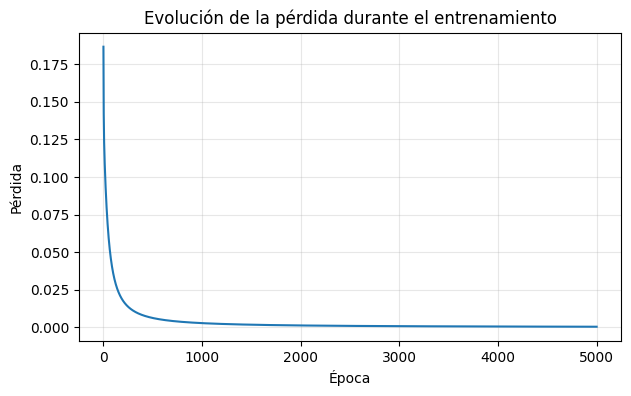

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Predicciones finales

In [11]:
y_prob = predict_proba(X, w, b)
y_pred = predict(X, w, b)

print("Probabilidades finales:")
print(np.round(y_prob, 4))

print("\nPredicciones finales:")
print(y_pred.astype(int))

print("\nEtiquetas reales:")
print(y.astype(int))

Probabilidades finales:
[[0.0336]
 [0.9789]
 [0.9789]
 [1.    ]]

Predicciones finales:
[[0]
 [1]
 [1]
 [1]]

Etiquetas reales:
[[0]
 [1]
 [1]
 [1]]


In [12]:
accuracy = np.mean(y_pred == y)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


## 7. Interpretación del modelo

La salida del modelo depende de:

\[
z = w_1 x_1 + w_2 x_2 + b
\]

La frontera de decisión se obtiene cuando \(z = 0\):

\[
w_1 x_1 + w_2 x_2 + b = 0
\]

En dos dimensiones, esta ecuación representa una recta.

In [13]:
w1, w2 = float(w[0, 0]), float(w[1, 0])
b0 = float(b[0, 0])

print(f"w1 = {w1:.4f}")
print(f"w2 = {w2:.4f}")
print(f"b  = {b0:.4f}")

w1 = 7.1991
w2 = 7.1991
b  = -3.3603


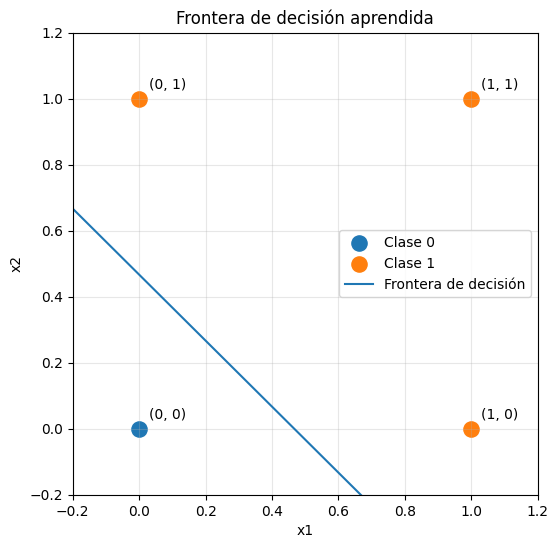

In [14]:
plt.figure(figsize=(6, 6))

mask0 = (y.ravel() == 0)
mask1 = (y.ravel() == 1)

plt.scatter(X[mask0, 0], X[mask0, 1], s=120, label="Clase 0")
plt.scatter(X[mask1, 0], X[mask1, 1], s=120, label="Clase 1")

# Recta de decisión: w1*x1 + w2*x2 + b = 0
x_vals = np.linspace(-0.2, 1.2, 200)

if abs(w2) > 1e-8:
    y_vals = -(w1 * x_vals + b0) / w2
    plt.plot(x_vals, y_vals, label="Frontera de decisión")
else:
    x_vertical = -b0 / w1
    plt.axvline(x_vertical, label="Frontera de decisión")

for i, (x1, x2) in enumerate(X):
    plt.text(x1 + 0.03, x2 + 0.03, f"({int(x1)}, {int(x2)})", fontsize=10)

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Frontera de decisión aprendida")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 8. Superficie de probabilidad

Visualizamos la probabilidad predicha por el modelo en el plano.

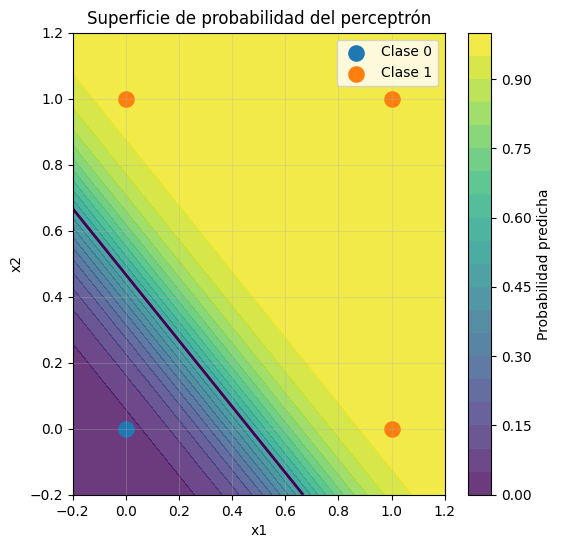

In [15]:
xx1 = np.linspace(-0.2, 1.2, 200)
xx2 = np.linspace(-0.2, 1.2, 200)
XX1, XX2 = np.meshgrid(xx1, xx2)

grid = np.column_stack([XX1.ravel(), XX2.ravel()])
probs = predict_proba(grid, w, b).reshape(XX1.shape)

plt.figure(figsize=(6, 6))
cont = plt.contourf(XX1, XX2, probs, levels=20, alpha=0.8)
plt.colorbar(cont, label="Probabilidad predicha")

plt.scatter(X[mask0, 0], X[mask0, 1], s=120, label="Clase 0")
plt.scatter(X[mask1, 0], X[mask1, 1], s=120, label="Clase 1")

plt.contour(XX1, XX2, probs, levels=[0.5], linewidths=2)

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Superficie de probabilidad del perceptrón")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 9. Caso opcional: XOR

El OR es linealmente separable. En cambio, el XOR no lo es:

| x1 | x2 | y |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Un perceptrón lineal no puede resolver correctamente este problema. Esto motiva el uso de modelos más complejos, como redes neuronales multicapa.

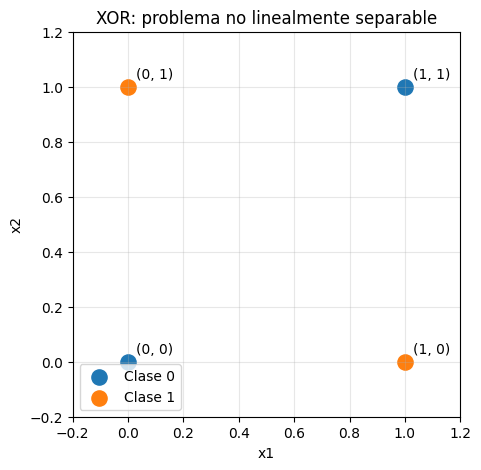

In [16]:
X_xor = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y_xor = np.array([[0.0],
                  [1.0],
                  [1.0],
                  [0.0]])

plt.figure(figsize=(5, 5))
mask0_xor = (y_xor.ravel() == 0)
mask1_xor = (y_xor.ravel() == 1)

plt.scatter(X_xor[mask0_xor, 0], X_xor[mask0_xor, 1], s=120, label="Clase 0")
plt.scatter(X_xor[mask1_xor, 0], X_xor[mask1_xor, 1], s=120, label="Clase 1")

for i, (x1, x2) in enumerate(X_xor):
    plt.text(x1 + 0.03, x2 + 0.03, f"({int(x1)}, {int(x2)})", fontsize=10)

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR: problema no linealmente separable")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 10. Conclusiones

En este ejemplo aparecen de forma integrada los conceptos del tema:

- **Datos**: vectores de entrada \((x_1, x_2)\)
- **Modelo**: perceptrón simple
- **Álgebra lineal**: combinación lineal \(w_1x_1 + w_2x_2 + b\)
- **Optimización**: descenso por gradiente
- **Geometría**: recta de separación entre clases

### Idea clave

Aprender un modelo significa encontrar los parámetros que mejor ajustan los datos.

## Ejercicios propuestos

1. Cambia la tasa de aprendizaje y observa cómo evoluciona la pérdida.
2. Prueba distintas inicializaciones aleatorias de los pesos.
3. Sustituye el MSE por entropía cruzada.
4. Intenta entrenar el mismo modelo sobre XOR. ¿Qué ocurre?
5. Representa la frontera de decisión durante varias épocas del entrenamiento.
---